In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [ ]:
df = pd.read_csv('train.csv')
df.head()



,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


Посмотрим на наши категориальные данные, что там вообще есть

In [3]:
print('Chest pain type	', df['Chest pain type'].unique(), '\n'
      'EKG results', df['EKG results'].unique(), '\n',
      'Slope of ST', df['Slope of ST'].unique())

Chest pain type	 [4 1 2 3] 
EKG results [0 2 1] 
 Slope of ST [2 1 3]


Проверим количество нулей и пропусков

In [4]:
df.isna().any().any()

np.False_

Супер. Разберемся тогда с выбросами. Попробуем через Граббса опять?(Не получилось, т.к. данные не имеют нормального распределения. По идее все равно можно было бы им воспользоваться, но результаты были бы сомнительными) Ну и не очень то хотелось. 1.5 IQR

In [5]:
cols_to_clean = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Thallium'] 
print('Before cleaning ', df.shape)
for col_name in cols_to_clean:
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3-q1
    l_bound = q1-1.5*iqr
    u_bound = q3 + 1.5*iqr
    df = df[(df[col_name] >= l_bound) &
            df[col_name] <= u_bound]
    
print('After cleaning ', df.shape)

Before cleaning  (630000, 15)
After cleaning  (630000, 15)


Гистограммы

Корреляция

In [20]:
hd_coding = {'Absence': 0, 'Presence': 1} 
df['HD Coded'] = df['Heart Disease'].map(hd_coding)
df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,HD Coded
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence,0
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence,0
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence,1
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence,1


<Axes: >

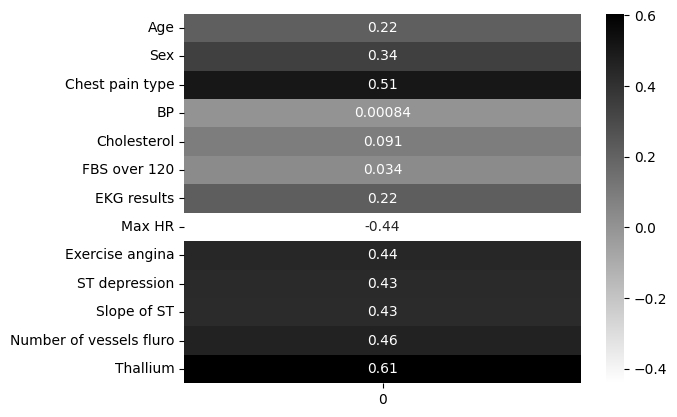

In [21]:
sns.heatmap(df.drop(columns=['id', 'Heart Disease', 'HD Coded']).corrwith(df['HD Coded'], method='spearman').to_frame(), annot=True, cmap='gray_r')
